In [27]:
library(tidyverse)
library(glue)
library(readr)
library(ggtext)
library(geomtextpath)
library(patchwork)
library(dplyr)


In [28]:
install.packages("ggtext")

In [29]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: aarch64-apple-darwin20.0.0 (64-bit)
Running under: macOS 15.7.4

Matrix products: default
BLAS/LAPACK: /Users/joonklaps/opt/anaconda3/envs/r-notebook/lib/libopenblas.0.dylib;  LAPACK version 3.12.0

locale:
[1] C/C.UTF-8/C/C/C/C

time zone: Europe/Brussels
tzcode source: system (macOS)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] patchwork_1.3.2    geomtextpath_0.2.0 ggtext_0.1.2       glue_1.8.0        
 [5] lubridate_1.9.4    forcats_1.0.0      stringr_1.5.2      dplyr_1.1.4       
 [9] purrr_1.1.0        readr_2.1.5        tidyr_1.3.1        tibble_3.3.0      
[13] ggplot2_3.5.2      tidyverse_2.0.0   

loaded via a namespace (and not attached):
 [1] bit_4.6.0          gtable_0.3.6       jsonlite_2.0.0     compiler_4.3.3    
 [5] crayon_1.5.3       Rcpp_1.1.0         tidyselect_1.2.1   IRdisplay_1.1     
 [9] xml2_1.4.0         parallel_4.3.3     systemfonts_1.

In [37]:
galn <- read_tsv("./data-preparation/global-alignment/global_alignment_stats.tsv")
refvref <- read_tsv("./data-preparation/global-alignment/refvref_global_alignment_stats.tsv")

Rows: 142 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (12): alignment_length, comparable_sites, matches, N_matches, mismatches...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 38 Columns: 14
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (2): seq1_id, seq2_id
dbl (12): alignment_length, comparable_sites, matches, N_matches, mismatches...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [38]:
head(galn)
head(refvref)

seq1_id,seq2_id,alignment_length,comparable_sites,matches,N_matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
U69588.1.9090_cl1_it2.consensus_bcftools,U69588.1,9252,9230,9084,0,1,0.000108,9230,9171,1,81,146,0
MZ766594.1.8282_cl1_it2.consensus_bcftools,MZ766594.1,9086,9080,9014,0,6,0.000661,9086,9085,0,1,66,0
AF443074.1.8384_cl4_it2.consensus_bcftools,AF443074.1,9338,7791,7548,0,1547,0.198562,9232,9037,106,301,243,0
KC156117.1.8484_cl4_it2.consensus_bcftools,_R_MN090277.1,11277,6101,6101,0,5176,0.848386,9223,9232,2054,2045,0,0
FJ670529.1.8687_cl1_it2.consensus_bcftools,FJ670529.1,9294,8058,7766,0,1236,0.153388,9232,8997,62,297,292,0
MT929422.1.8888_cl1_it2.consensus_bcftools,MT929422.1,11963,6949,6949,0,5013,0.721399,9128,9783,2835,2179,0,0


seq1_id,seq2_id,alignment_length,comparable_sites,matches,N_matches,mismatches,mismatch_rate,seq1_length,seq2_length,seq1_gaps,seq2_gaps,seq1_Ns,seq2_Ns
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MN090277.1,MN090277.1,9232,9232,9232,0,0,0.000000,9232,9232,0,0,0,0
MN090277.1,MZ766594.1,9370,7522,7522,0,1848,0.245679,9232,9085,138,285,0,0
MN090277.1,HM215250.1,10086,8266,6414,0,1815,0.219574,9232,9611,854,470,0,1852
MN090277.1,FJ670529.1,9296,7820,7820,0,1476,0.188747,9232,8997,64,299,0,0
MN090277.1,K02013.1,9355,8301,8301,0,1054,0.126973,9232,9229,123,126,0,0
MN090277.1,AF443074.1,9338,7604,7604,0,1734,0.228038,9232,9037,106,301,0,0


In [39]:
best_match <- galn%>%group_by(seq1_id)%>%
  arrange(desc(matches))%>%
  slice(1)%>%
  select(seq1_id, best_match=seq2_id)

In [40]:
refvref_orderd <- refvref %>%
    mutate(target = seq2_id, fident = (matches + N_matches) / alignment_length, semi_fident = comparable_sites / alignment_length) %>%
    arrange(desc(fident), desc(semi_fident)) %>%
    select(target, fident, semi_fident)

In [41]:
selection <- galn%>%
    mutate(target=sub("^([^.]+\\.[^.]+).*", "\\1", seq1_id))%>%
    merge(best_match, by="seq1_id")%>%
    merge(., refvref_orderd, by="target", all.x=TRUE)%>%
    filter(seq2_id == "MN090277.1")%>%
    filter(comparable_sites/alignment_length >= 0.7) # Alignment needs to be somewhat comparable


summary(selection$semi_fident)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7483  0.8085  0.8412  0.8484  0.8698  1.0000 

Warning message in dir.create("./images"):
“'./images' already exists”


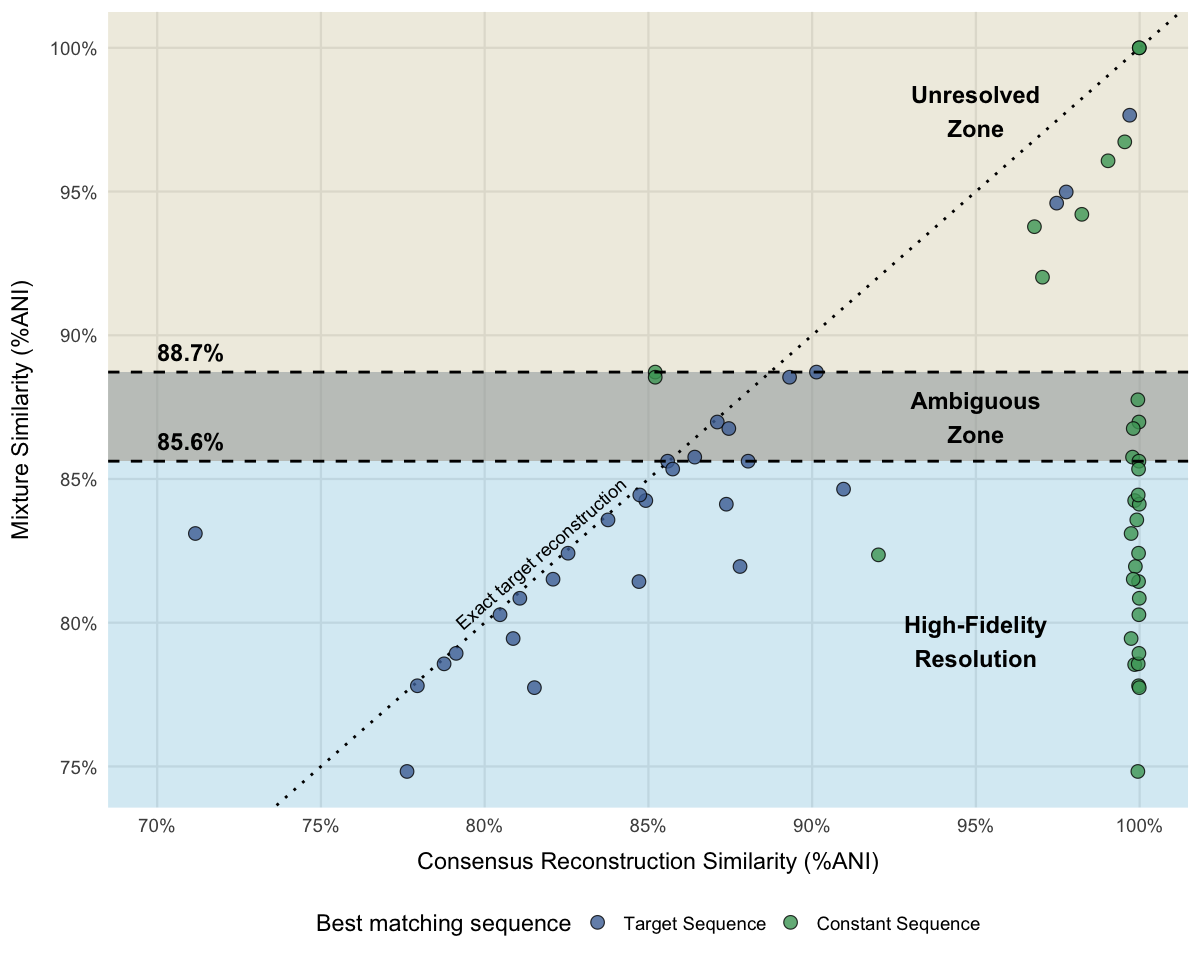

In [42]:
options(repr.plot.width = 10, repr.plot.height = 8)

# Calculate thresholds
threshold1 <- selection %>%
    group_by(target) %>%
    unique() %>%
    filter(n() > 1) %>%
    ungroup() %>%
    summarise(threshold = max(fident)) %>%
    pull(threshold)

threshold2 <- selection %>%
    group_by(target) %>%
    unique() %>%
    filter(n() > 1)%>%
    filter(abs((comparable_sites/alignment_length) - fident) < 0.001) %>%
    ungroup() %>%
    summarise(threshold = max(fident)) %>%
    pull(threshold)

p <- ggplot(selection, aes(x = comparable_sites/alignment_length, y = semi_fident, fill = (best_match == "MN090277.1"))) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = threshold1,
             fill = "#77BEDB", alpha = 0.3) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = threshold1, ymax = threshold2,
             fill = "#7F6E85", alpha = 0.3) +
    annotate("rect", xmin = -Inf, xmax = Inf, ymin = threshold2, ymax = Inf,
             fill = "#CCC197", alpha = 0.3) +
    geom_textabline(linetype = "dotted", slope = 1, intercept = 0, color = "black", linewidth = 0.8, label ="Exact target reconstruction", hjust = 0.3, vjust=-0.2 ) +
    geom_point(size = 3.5, alpha = 0.8, shape = 21, color = "black") +
    geom_hline(yintercept = threshold1, linetype = "dashed", color = "black", linewidth = 0.8) +
    geom_hline(yintercept = threshold2, linetype = "dashed", color = "black", linewidth = 0.8) +
    # Points
    # Labels
    annotate("text", x = 0.70, y = threshold1 + 0.007,
             label = sprintf("%.1f%%", threshold1 * 100),
             color = "black", fontface = "bold", size = 5, hjust = 0) +
    annotate("text", x = 0.70, y = threshold2 + 0.007,
             label = sprintf("%.1f%%", threshold2 * 100),
             color = "black" , fontface = "bold", size = 5, hjust = 0) +
    # Zone labels
    annotate("text", x = 0.95, y =(threshold2 + 1.10) / 2,
             label = "Unresolved\nZone", fontface = "bold", size = 5, color = "black") +
    annotate("text", x = 0.95, y = (threshold1 + threshold2) / 2,
             label = "Ambiguous\nZone", fontface = "bold", size = 5, color = "black") +
    annotate("text", x = 0.95, y =  (0.70 + threshold1) / 2,
             label = "High-Fidelity\nResolution", fontface = "bold", size = 5, color = "black") +
    # Scales
    scale_fill_manual(values=c("#4C72A5","#48A365"), labels =c("Representative genome", "Constant genome (MN090277.1)")) +
    scale_x_continuous(labels = scales::percent_format(accuracy = 1),
                       breaks = scales::pretty_breaks(n = 6)) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1),
                       breaks = scales::pretty_breaks(n = 6)) +
    labs(x = "ANI reconstructed consensus vs constant genome (%ANI)",
         y = "ANI representative genome vs constant genome (%ANI)",
         fill = "Best-matching genome"
        ) +
    theme_minimal(base_size = 14) +
    theme(
        axis.title.x = element_text(margin = margin(t = 10)),
        axis.title.y = element_text(margin = margin(r = 10)),
        panel.grid.minor = element_blank(),
        panel.background = element_blank(),
        plot.background = element_blank(),
        legend.position = "bottom",
        plot.title = element_text(hjust = 0.5, face = "bold")
    )

p
dir.create("./images")
# ggsave("./images/reference_impact_zones.png", plot = p, width = 10, height = 8, dpi = 300)
# ggsave("../../../Fig/supplfig1.png", plot = p, width = 10, height = 8, dpi = 300)

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


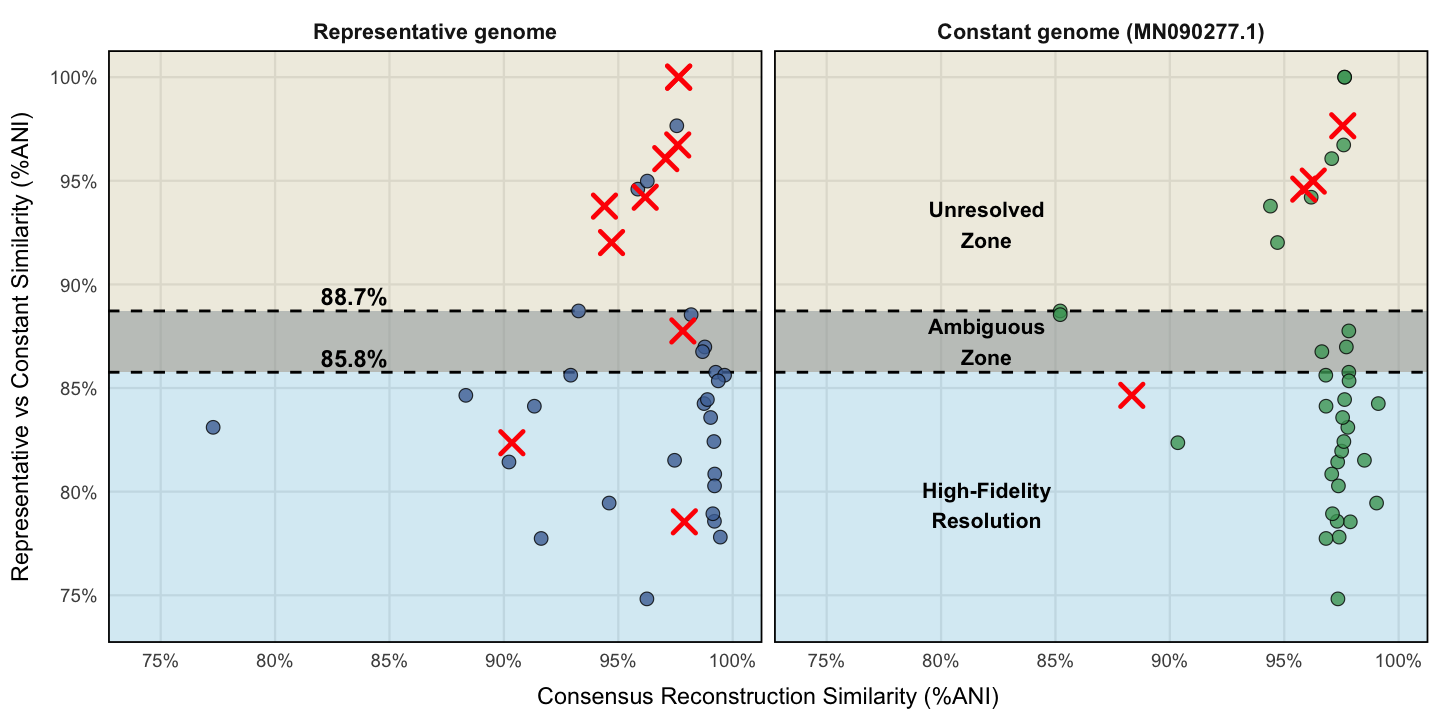

In [55]:
options(repr.plot.width = 12, repr.plot.height = 6)

# ── Thresholds ────────────────────────────────────────────────────────────────
threshold1 <- selection %>%
    group_by(target) %>% unique() %>%
    filter(n() > 1) %>% ungroup() %>%
    summarise(threshold = max(fident)) %>% pull(threshold)

threshold2 <- selection %>%
    group_by(target) %>% unique() %>%
    filter(n() > 1) %>%
    filter(abs(((matches) / alignment_length) - fident) < 0.001) %>%
    ungroup() %>%
    summarise(threshold = max(fident)) %>% pull(threshold)

# ── Prepare data ──────────────────────────────────────────────────────────────
target_similarity <- galn %>%
    mutate(target = sub("^([^.]+\\.[^.]+).*", "\\1", seq1_id)) %>%
    filter(seq2_id == target) %>%
    group_by(seq1_id, target) %>%
    summarise(target_similarity = max((matches) / alignment_length), .groups = "drop")

df <- selection %>%
    left_join(target_similarity, by = c("seq1_id", "target")) %>%
    mutate(isConstant = best_match == "MN090277.1") %>%
    # distance uses panel-specific reference similarity
    mutate(dist_x = if_else(isConstant,
                            (matches) / alignment_length,
                            coalesce(target_similarity, (matches)  / alignment_length)))

# Targets that are missing one of the two reference types → red X
targets_with_both <- df %>%
    group_by(target) %>%
    summarise(has_constant = any(isConstant), has_target = any(!isConstant)) %>%
    filter(!has_constant | !has_target)

missing_x <- df %>%
    inner_join(targets_with_both, by = "target") %>%
    # In constant panel: show X if has_constant is FALSE (take the target-ref row)
    # In target panel:   show X if has_target  is FALSE (take the constant-ref row)
    # We duplicate the row once per missing panel
    mutate(
        show_in_constant = !has_constant,
        show_in_target   = !has_target
    ) %>%
    tidyr::pivot_longer(cols = c(show_in_constant, show_in_target),
                        names_to = "panel", values_to = "show") %>%
    filter(show) %>%
    mutate(isConstant = panel == "show_in_constant")

# ── Plot ──────────────────────────────────────────────────────────────────────
p <- ggplot(df, aes(x = dist_x, y = semi_fident, fill = isConstant)) +
    # Zone backgrounds
    annotate("rect", xmin=-Inf, xmax=Inf, ymin=-Inf,       ymax=threshold1, fill="#77BEDB", alpha=0.3) +
    annotate("rect", xmin=-Inf, xmax=Inf, ymin=threshold1, ymax=threshold2, fill="#7F6E85", alpha=0.3) +
    annotate("rect", xmin=-Inf, xmax=Inf, ymin=threshold2, ymax=Inf,        fill="#CCC197", alpha=0.3) +
    # Threshold lines
    geom_hline(yintercept = threshold1, linetype="dashed", linewidth=0.8) +
    geom_hline(yintercept = threshold2, linetype="dashed", linewidth=0.8) +
    # Data points
    geom_point(size=3.5, alpha=0.8, shape=21, color="black") +
    # Missing reference X markers
    geom_point(data = missing_x,
                aes(x = dist_x, y = semi_fident),
                shape=4, color="red", size=5, stroke=2, inherit.aes=FALSE) +
    # Threshold value labels + zone labels only drawn in constant (left) panel
    geom_text(data = data.frame(
                    isConstant = FALSE,
                    dist_x     = 0.27,
                    semi_fident = c(threshold1 + 0.007, threshold2 + 0.007),
                  label       = sprintf("%.1f%%", c(threshold1, threshold2) * 100)),
              aes(y = semi_fident, x = 0.80 , label=label), fontface="bold", size=5, hjust=0, inherit.aes=FALSE, nudge_x = 0.02) +
    geom_text(data = data.frame(
                    isConstant  = TRUE,
                    dist_x      = 0.25,
                    semi_fident = c((threshold2+1.00)/2, (threshold1+threshold2)/2, (0.70+threshold1)/2),
                    label       = c("Unresolved\nZone", "Ambiguous\nZone", "High-Fidelity\nResolution")),
              aes(y = semi_fident, x = 0.80 , label=label), fontface="bold", size=4.5, inherit.aes=FALSE, nudge_x = 0.02) +
    # Facet
    facet_wrap(~ factor(isConstant, levels = c(TRUE, FALSE),
                         labels = c("Constant genome (MN090277.1)", "Representative genome"))) +
    scale_fill_manual(values  = c("FALSE" = "#4C72A5", "TRUE" = "#48A365"),
                      labels  = c("FALSE" = "Representative genome", "TRUE" = "Constant genome"),
                      guide   = "none") +
    scale_x_continuous(labels = scales::percent_format(accuracy=1),
                       breaks = scales::pretty_breaks(n=6), limits = c(0.74, 1.00)) +
    scale_y_continuous(labels = scales::percent_format(accuracy=1),
                       breaks = scales::pretty_breaks(n=6), limits = c(0.74, 1.00)) +
    labs(x = "Consensus Reconstruction Similarity (%ANI)",
         y = "ANI representative genome vs constant genome (%ANI)") +
    theme_minimal(base_size=14) +
    theme(
        axis.title.x      = element_text(margin=margin(t=10)),
        axis.title.y      = element_text(margin=margin(r=10)),
        panel.grid.minor  = element_blank(),
         panel.border     = element_rect(colour = "black", fill=NA, linewidth=1),
        # panel.spacing     = unit(0, "lines"),   # zero gap between panels
        strip.text        = element_text(face="bold", size=13),
        legend.position   = "bottom"
    )

p

# dir.create("./images", showWarnings=FALSE)
ggsave("./images/reference_impact_zones.png", plot=p, width=12, height=6, dpi=300)
ggsave("../../../Fig/supplfig1.png",           plot=p, width=12, height=6, dpi=300)